<a href="https://colab.research.google.com/github/chamarairesh1982/LearnPython/blob/main/chamara_Week_4_Linear_and_Multiple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1. Load the Dataset

In [ ]:
from google.colab import files
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Load the Dataset
uploaded = files.upload()

df = pd.read_csv("housing.csv")

Saving housing.csv to housing.csv


In [ ]:
print(df.shape)
print(df.columns)
df.head()

(20640, 10)
Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


# Task 2. Exploratory Data Analysis (EDA)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


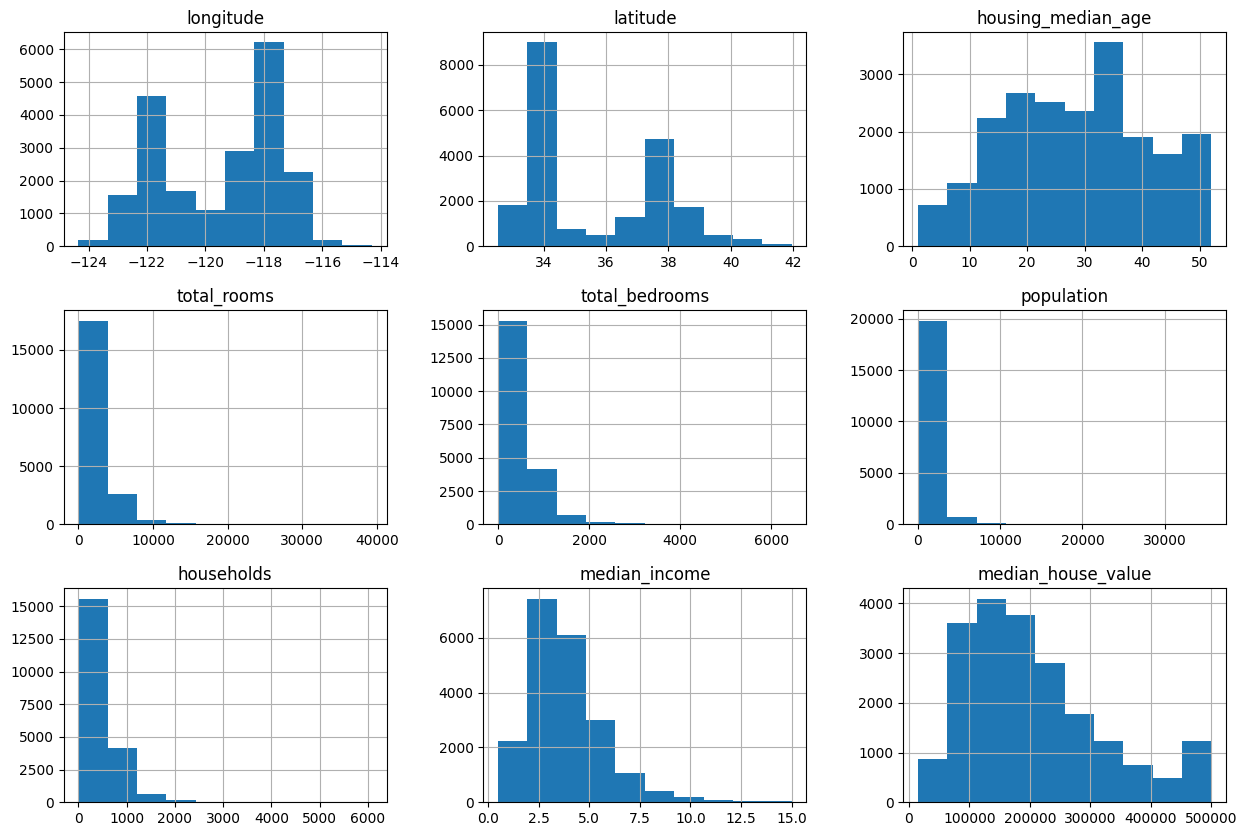

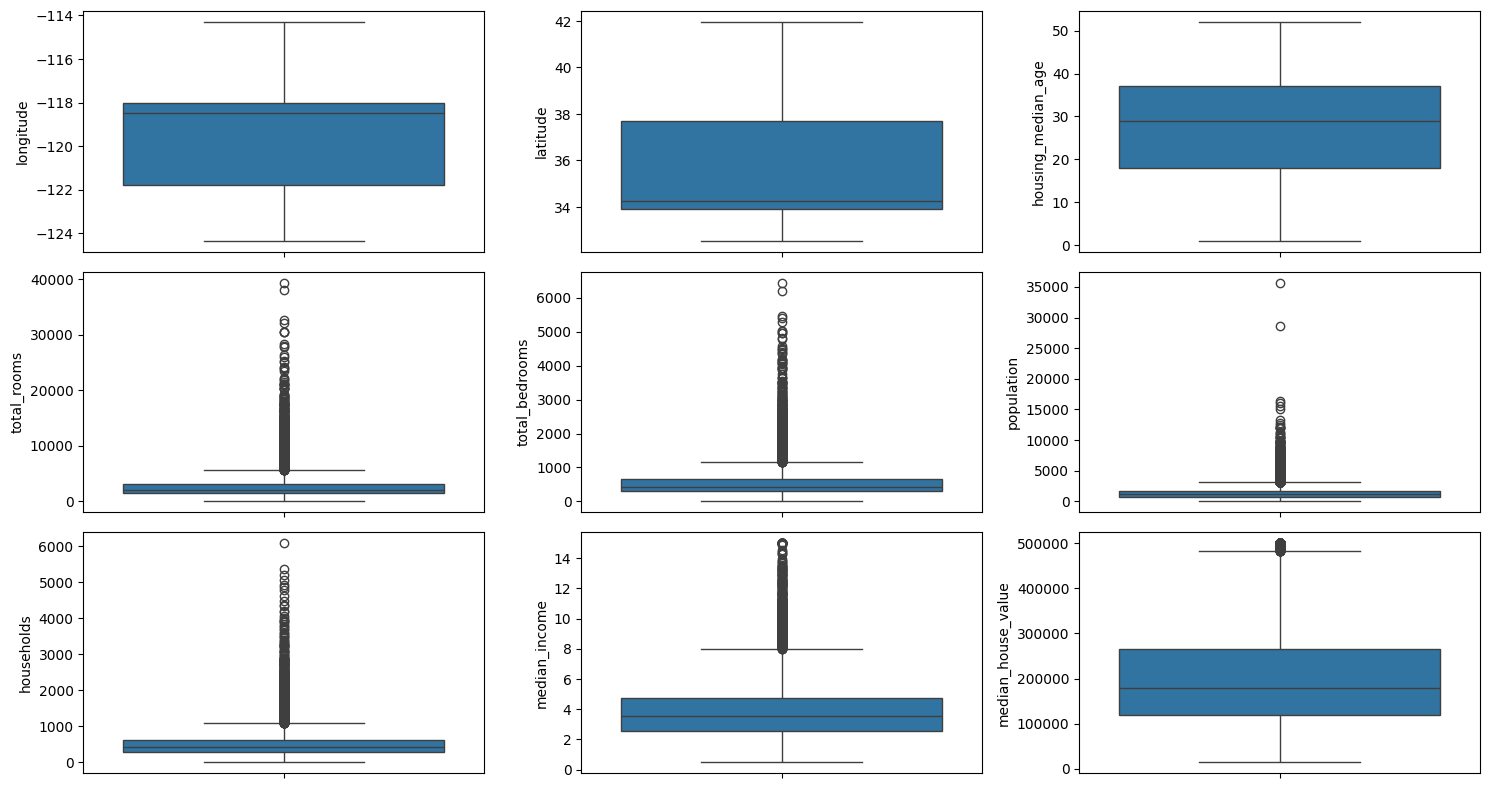

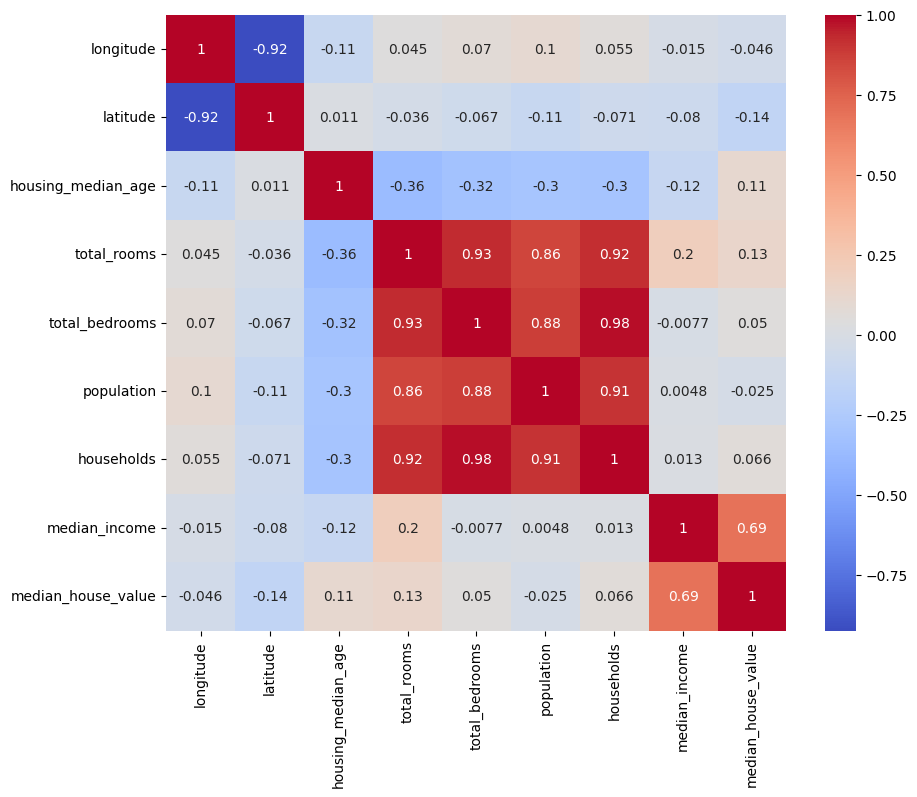

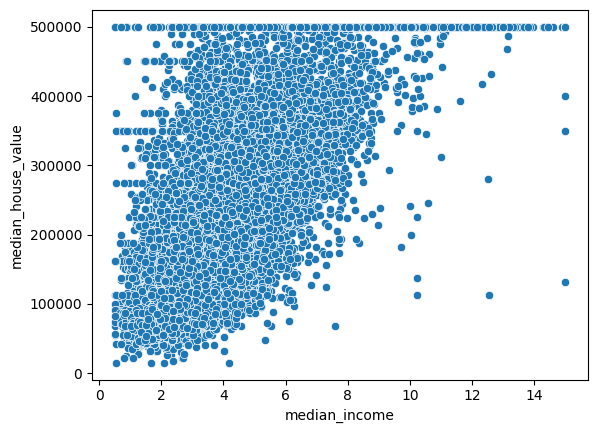

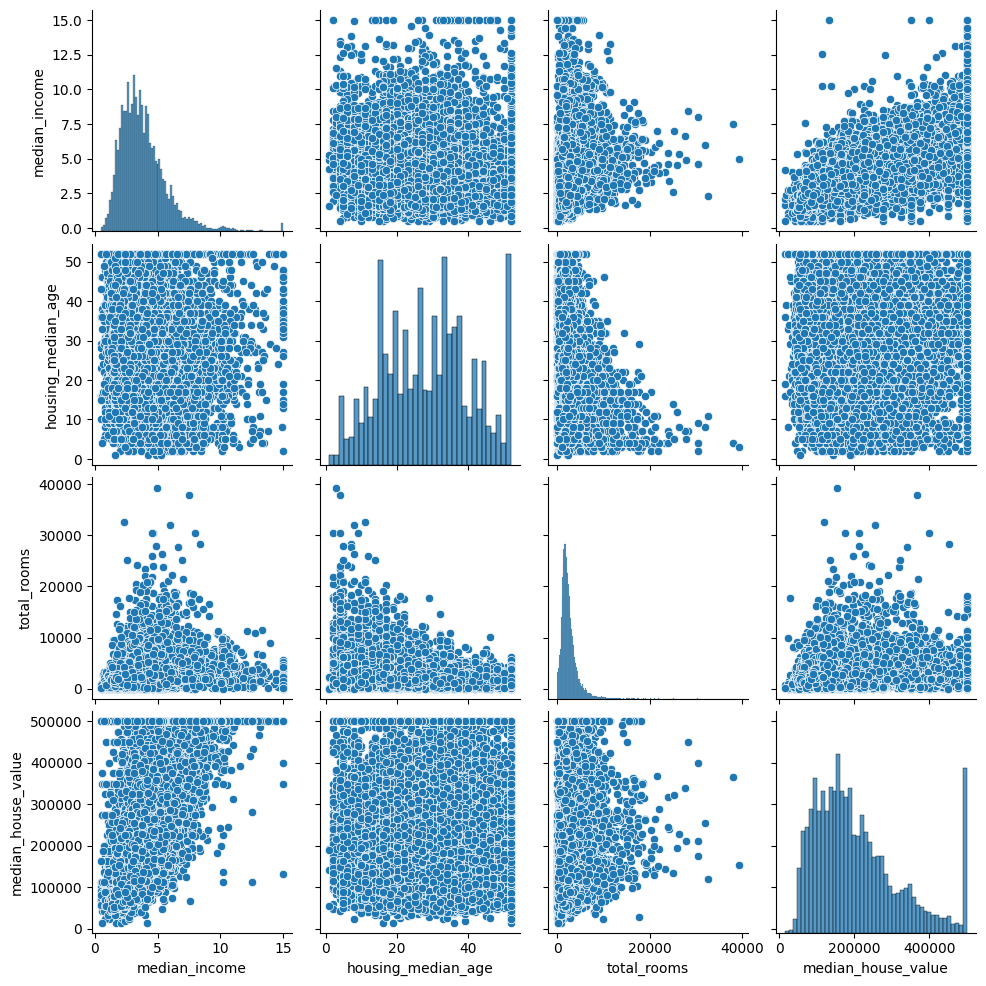

In [ ]:
df.info()   # Dataset Information, Data types and non-null counts
df.describe()  # Summary statistics for numerical features
df.isnull().sum()  # Check for Missing Values
df.duplicated().sum()  # Duplicate Records
df["ocean_proximity"].value_counts()  # Unique Categories

df.hist(figsize=(15,10))  # Histograms
plt.show()

numerical=df.select_dtypes(include=['int64','float64']) # Boxplots - Only numerical columns

plt.figure(figsize=(15,8))

for i,col in enumerate(numerical.columns):
    plt.subplot(3,3,i+1)
    sns.boxplot(y=df[col])

plt.tight_layout()
plt.show()
plt.figure(figsize=(10,8))   # Correlation Heatmap

sns.heatmap(
    numerical.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.show()

sns.scatterplot(  # Scatter Plot between median income and house value
    data=df,
    x="median_income",
    y="median_house_value"
)

sns.pairplot(     # Pair Plot
    df[
        [
            "median_income",
            "housing_median_age",
            "total_rooms",
            "median_house_value"
        ]
    ]
)

plt.show()

# Task 3 – Data Preprocessing

In [ ]:
# Handle missing values and duplicates
# Median imputation is a safe default for a right-skewed numeric feature
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())
df = df.drop_duplicates()

#Feature engineering
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

# One-hot encode the categorical feature
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

#Train-test split
from sklearn.model_selection import train_test_split

X = df.drop(columns=['median_house_value'])
y = df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)



(16512, 15) (4128, 15)


# Task 4. Simple Linear Regression Model

w1 - Coefficient: 41933.84939381272
w0 - Intercept: 44459.72916907875
R2: 0.45885918903846656
RMSE: 84209.01241414454
MAE: 62990.86530093761


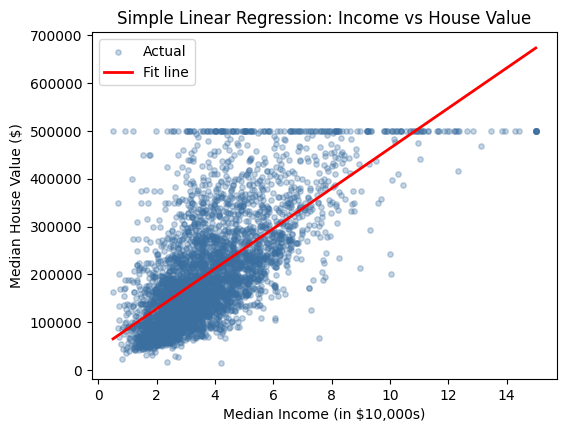

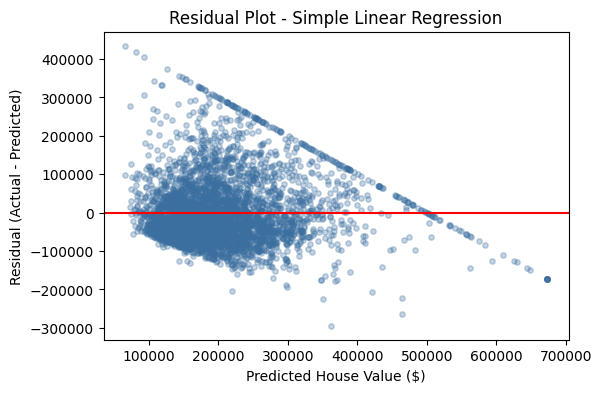

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Select the correct columns for Features and target
X_simple = df[['median_income']] # Independent variable
y = df['median_house_value'] # Dependent variable (target: house value)

# Train-test split (Split the data into training and testing sets)
# The model learns from X_train and y_train
# After training, we give X_test to the model and ask: “Can you predict the house values for these new observations?” Then we compare the predictions with y_test.
# test_size=0.2 means 20% of the data is reserved for testing.
# When splitting the dataset, Python randomly selects which observations go into training and testing.random_state=42 makes that random selection reproducible.
X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42)

# Model creation and training  (Initialize the Linear Regression model)
lr = LinearRegression()
lr.fit(X_train, y_train)  # Train the model
y_pred = lr.predict(X_test) # Predictions (Make predictions on the test set)

# Printing coefficient values
print('w1 - Coefficient:', lr.coef_[0])
print('w0 - Intercept:', lr.intercept_)

# Model Evaluation
# R2: how much of the variation in house prices can be explained by our model using median income.
print('R2:', r2_score(y_test, y_pred))  #R² close to 1 → very good fit
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))
print('MAE:', mean_absolute_error(y_test, y_pred))

# Visualise the fit and its residuals
plt.figure(figsize=(6,4.5))
plt.scatter(X_test, y_test, alpha=0.3, color='#3b6fa0', s=15, label='Actual')
order = np.argsort(X_test.values[:,0])
plt.plot(X_test.values[order], y_pred[order], color='red', linewidth=2, label='Fit line')
plt.title('Simple Linear Regression: Income vs House Value')
plt.xlabel('Median Income (in $10,000s)'); plt.ylabel('Median House Value ($)')
plt.legend()
plt.show()

# A residual is simply the difference between the actual value and the predicted value.
# Positive residual → model predicted too low, Negative residual → model predicted too high, Residual = 0 → perfect prediction
# The residual plot shows how the errors are distributed.
residuals = y_test - y_pred
plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.3, color='#3b6fa0', s=15)
plt.axhline(0, color='red', linewidth=1.5)
plt.title('Residual Plot - Simple Linear Regression')
plt.xlabel('Predicted House Value ($)'); plt.ylabel('Residual (Actual - Predicted)')
plt.show()
# There is a noticeable funnel/triangular pattern. Therefore, the errors are not evenly distributed across the predicted values.
# This suggests that the Simple Linear Regression model is not capturing the relationship between median income and house value particularly well.

# Task 5. Multiple Linear Regression

R2: 0.5970176824350761
RMSE: 72668.53837868226
MAE: 50888.66001572008
latitude                     -56638.231159
longitude                    -56276.058852
population                   -46320.285471
ocean_proximity_INLAND       -16257.039232
ocean_proximity_NEAR BAY      -1718.333533
population_per_household        750.367943
ocean_proximity_NEAR OCEAN      996.583711
ocean_proximity_ISLAND         2034.426108
total_bedrooms                 5307.662997
total_rooms                    5881.104980
rooms_per_household            7699.448488
housing_median_age            14122.304752
bedrooms_per_room             16809.104551
households                    40233.724848
median_income                 78904.439397
dtype: float64


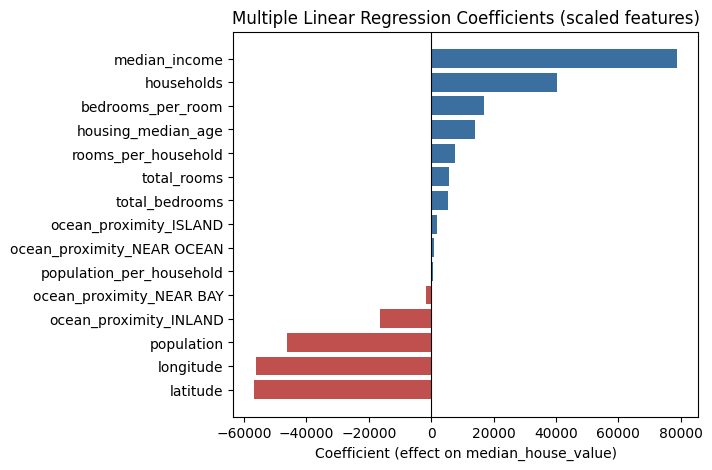

In [ ]:
from sklearn.preprocessing import StandardScaler # Imports

# Features and target
X = df.drop(columns=['median_house_value'])  # Multiple independent variables
y = df['median_house_value']  # Dependent variable (target: house value)

# Train-test split (Split the data into training and testing sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model creation and training (Initialize the Multiple Linear Regression model)
lr_multi = LinearRegression()
lr_multi.fit(X_train_scaled, y_train)
y_pred_multi = lr_multi.predict(X_test_scaled)  # Make predictions on the test set

# Model Evaluation
print('R2:', r2_score(y_test, y_pred_multi))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_multi)))
print('MAE:', mean_absolute_error(y_test, y_pred_multi))

# Inspect coefficients (# Coefficients of the model (showing the importance of each feature))
coeffs = pd.Series(lr_multi.coef_, index=X.columns).sort_values()
print(coeffs)

plt.figure(figsize=(6,5))
colors = ['#c0504d' if v < 0 else '#3b6fa0' for v in coeffs.values]
plt.barh(coeffs.index, coeffs.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Multiple Linear Regression Coefficients (scaled features)')
plt.xlabel('Coefficient (effect on median_house_value)')
plt.show()



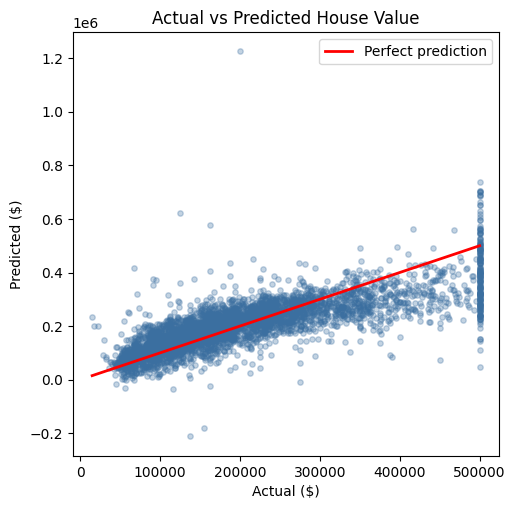

In [ ]:
# Actual vs Predicted plot
plt.figure(figsize=(5.5,5.5))
plt.scatter(y_test, y_pred_multi, alpha=0.3, color='#3b6fa0', s=15)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, color='red', linewidth=2, label='Perfect prediction')
plt.title('Actual vs Predicted House Value')
plt.xlabel('Actual ($)'); plt.ylabel('Predicted ($)'); plt.legend()
plt.show()

